# PitWall Intelligence — Notebook 03: Exploratory Data Analysis
**Sprint 1 | Data Acquisition & EDA**

Answers the core business questions that motivate the BVI model:
1. How do constructor points and standings vary across the hybrid era?
2. Which teams show consistent vs. volatile performance?
3. Is qualifying pace correlated with race performance?
4. Where do DNFs cluster — which teams/seasons have reliability issues?
5. What does the constructor points distribution look like? (BVI implication: is value concentrated?)

All charts are saved to `reports/` for the Sprint 1 progress report.

In [1]:
# ── Cell 1: Setup ───────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = '/content/drive/MyDrive/PitWall'
DB_PATH      = f'{PROJECT_ROOT}/data/pitwall.db'
REPORTS_DIR  = f'{PROJECT_ROOT}/reports'
Path(REPORTS_DIR).mkdir(parents=True, exist_ok=True)

# F1 team brand colours (approx.)
TEAM_COLOURS = {
    'mercedes':    '#00D2BE',
    'red_bull':    '#1E41FF',
    'ferrari':     '#DC0000',
    'mclaren':     '#FF8000',
    'alpine':      '#0090FF',
    'renault':     '#FFD700',
    'aston_martin':'#006F62',
    'williams':    '#005AFF',
    'haas':        '#FFFFFF',
    'alfa':        '#900000',
    'sauber':      '#52E252',
    'alphatauri':  '#2B4562',
    'toro_rosso':  '#2B4562',
    'racing_point':'#F596C8',
    'force_india': '#F596C8',
    'lotus_f1':    '#FFD700',
    'manor':       '#FF0000',
    'caterham':    '#005030',
    'rb':          '#1E41FF',
}

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
print('Ready.')

Mounted at /content/drive
Ready.


In [7]:
import os

# ── Cell 2: Load preprocessed data ─────────────────────────────────────────
if not os.path.exists(DB_PATH):
    print(f"Error: Database file not found at {DB_PATH}. Please ensure the database is in the correct location.")
else:
    with sqlite3.connect(DB_PATH) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        table_names = [table[0] for table in tables]

        print(f"Tables found in database: {table_names}")

        try:
            # Use available table names and adjust column names as per schema
            ts   = pd.read_sql('SELECT * FROM constructor_standings', conn)
            qual = pd.read_sql('SELECT * FROM qualifying',  conn)
            res  = pd.read_sql('SELECT * FROM results', conn)
            races= pd.read_sql('SELECT * FROM races', conn)

            # Renaming columns to match original notebook's expectations if necessary
            # For constructor_standings, 'points' is the column for total points
            ts = ts.rename(columns={'points': 'total_points', 'constructorId': 'constructor_id', 'position': 'season_rank'})
            # For qualifying, will need to check columns later for 'qual_times_clean'
            # For results, need to check columns for 'total_dnfs' and 'races_entered'

            # Focus on top 6 teams for readability - using 'total_points' from constructor_standings
            TOP6 = ts.groupby('constructor_id')['total_points'].sum().nlargest(6).index.tolist()

            print(f'Seasons: {sorted(ts.season.unique())}')
            print(f'Top 6 by total points: {TOP6}')
        except Exception as e:
            print(f"An error occurred while loading data: {e}")
            print("Please check the table names and column names in your SQL queries against the list above and table schemas.")

Tables found in database: ['races', 'sqlite_sequence', 'results', 'qualifying', 'constructor_standings', 'driver_standings', 'constructors', 'drivers']
Seasons: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Top 6 by total points: ['mercedes', 'red_bull', 'ferrari', 'mclaren', 'williams', 'force_india']


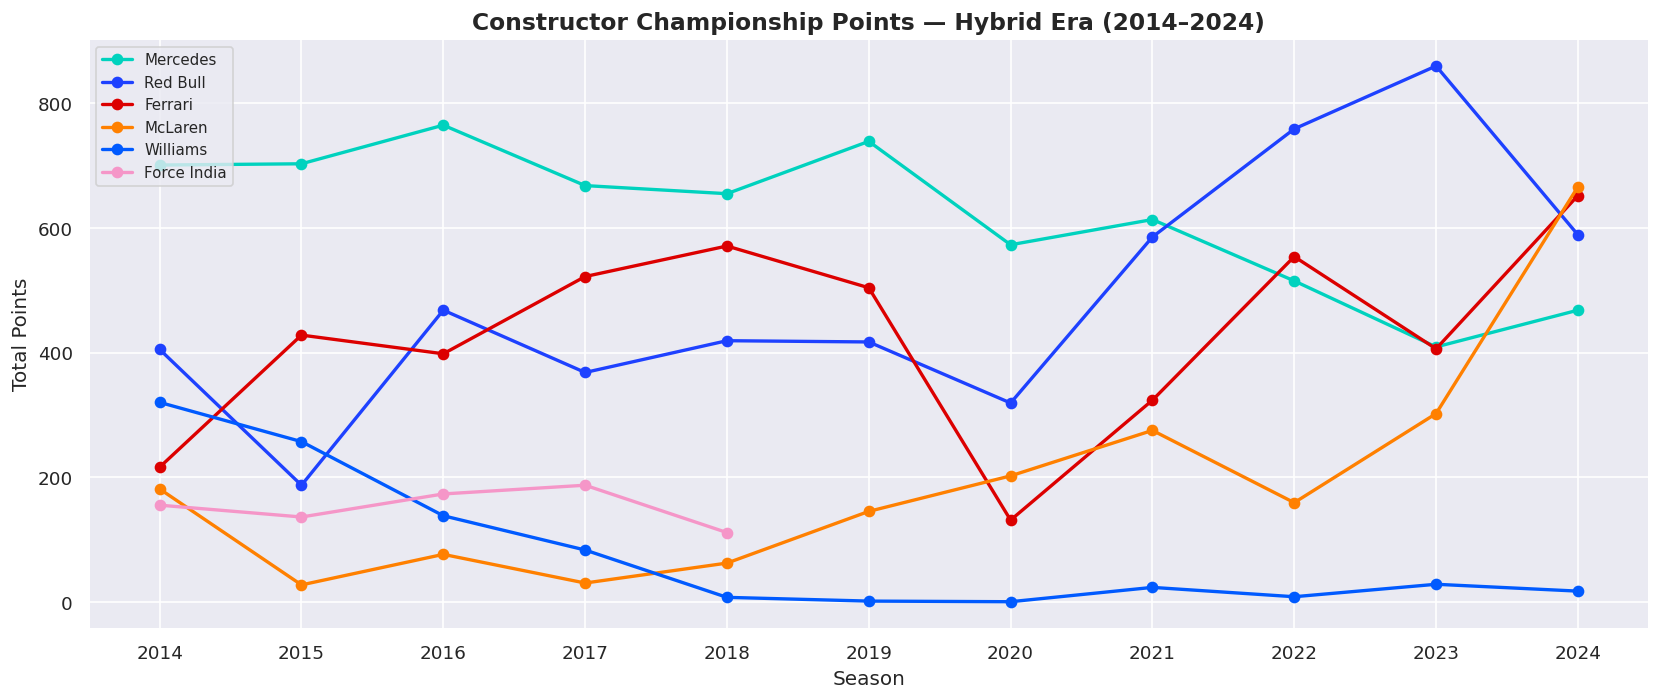

Saved: eda_01_points_trend.png


In [11]:
# ── EDA 1: Constructor points trend 2014–2024 ───────────────────────────────
import sqlite3

# Load constructors table to get names, if not already loaded
# This assumes DB_PATH is available from a previous cell
if 'constructors_df' not in globals():
    with sqlite3.connect(DB_PATH) as conn:
        constructors_df = pd.read_sql('SELECT constructor_id, name, nationality, url FROM constructors', conn)
        # The column name is already 'constructor_id', no renaming needed here

# Merge ts with constructors_df to get the 'name' column
ts_with_names = pd.merge(ts, constructors_df, on='constructor_id', how='left')

fig, ax = plt.subplots(figsize=(14, 6))

for cid in TOP6:
    # Use the ts_with_names DataFrame for plotting
    sub  = ts_with_names[ts_with_names['constructor_id'] == cid].sort_values('season')
    if not sub.empty: # Check if sub is not empty before accessing .iloc[0]
        name = sub['name'].iloc[0]
        colour = TEAM_COLOURS.get(cid, None)
        ax.plot(sub['season'], sub['total_points'], marker='o',
                label=name, color=colour, linewidth=2)

ax.set_title('Constructor Championship Points — Hybrid Era (2014–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Total Points')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(range(2014, 2025))
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_01_points_trend.png', dpi=150)
plt.show()
print('Saved: eda_01_points_trend.png')

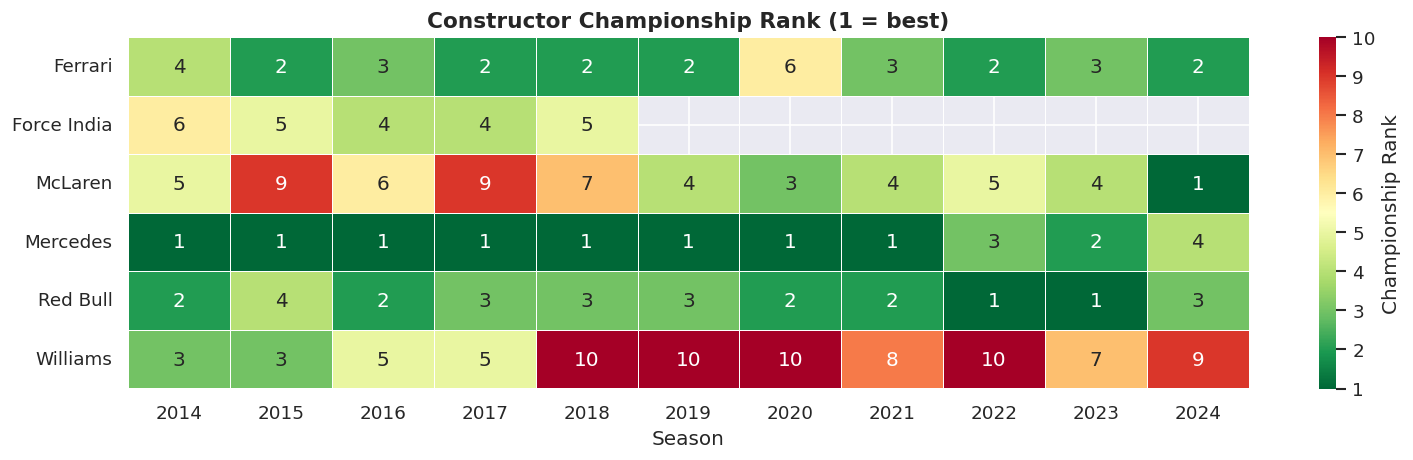

Saved: eda_02_standings_heatmap.png


In [13]:
pivot = ts_with_names[ts_with_names['constructor_id'].isin(TOP6)].pivot(
    index='name', columns='season', values='season_rank'
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Championship Rank'})
ax.set_title('Constructor Championship Rank (1 = best)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_02_standings_heatmap.png', dpi=150)
plt.show()
print('Saved: eda_02_standings_heatmap.png')

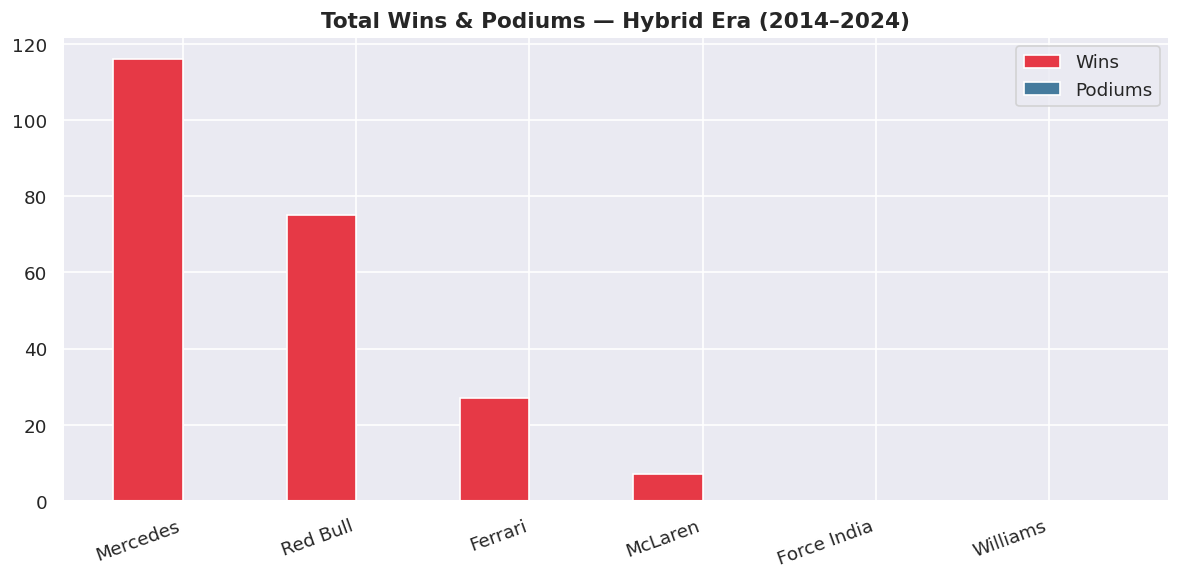

In [16]:
# ── EDA 3: Wins & podiums bar — 2014–2024 totals ────────────────────────────

# Calculate season podiums from 'res' DataFrame
# Filter for positions 1, 2, or 3
podium_results = res[res['position_order'].isin([1, 2, 3])]
# Count podiums per constructor per season
season_podiums_df = podium_results.groupby(['season', 'constructor_id']).size().reset_index(name='season_podiums')

# Merge season_podiums_df with ts_with_names
# Using a temporary DataFrame to avoid modifying ts_with_names globally for this specific plot
# and to ensure data is available for aggregation
temp_df_for_agg = pd.merge(ts_with_names, season_podiums_df, on=['season', 'constructor_id'], how='left')
# Fill NaN values with 0 for constructors/seasons with no podiums
temp_df_for_agg['season_podiums'] = temp_df_for_agg['season_podiums'].fillna(0).astype(int)

totals = temp_df_for_agg[temp_df_for_agg['constructor_id'].isin(TOP6)].groupby(['name','constructor_id']).agg(
    wins    = ('wins',    'sum'),       # Use the existing 'wins' column from ts_with_names
    podiums = ('season_podiums', 'sum') # Use the newly calculated 'season_podiums'
).reset_index().sort_values('wins', ascending=False)

x     = range(len(totals))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], totals['wins'],   width, label='Wins',    color='#e63946')
ax.bar([i + width/2 for i in x], totals['podiums'], width, label='Podiums', color='#457b9d')
ax.set_xticks(list(x))
ax.set_xticklabels(totals['name'], rotation=20, ha='right')
ax.set_title('Total Wins & Podiums — Hybrid Era (2014–2024)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_03_wins_podiums.png', dpi=150)
plt.show()

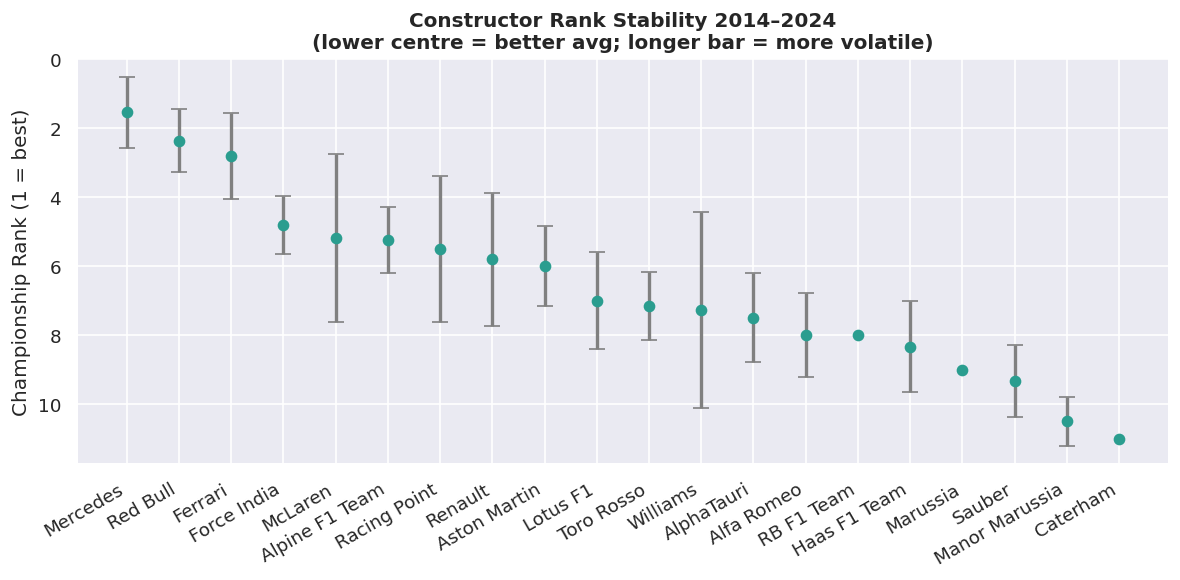

In [19]:
# ── EDA 4: Performance consistency (std dev of season rank) ─────────────────
# BVI implication: consistent teams are lower-risk sponsors
stability = ts_with_names.groupby(['name','constructor_id'])['season_rank'].agg(['mean','std']).reset_index()
stability.columns = ['name','constructor_id','avg_rank','rank_std']
stability = stability.sort_values('avg_rank')

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(stability['name'], stability['avg_rank'],
            yerr=stability['rank_std'], fmt='o', capsize=5,
            color='#2a9d8f', ecolor='grey', linewidth=2)
ax.invert_yaxis()  # rank 1 at top
ax.set_title('Constructor Rank Stability 2014–2024\n(lower centre = better avg; longer bar = more volatile)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Championship Rank (1 = best)')
ax.set_xticks(range(len(stability['name'])))
ax.set_xticklabels(stability['name'], rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_04_consistency.png', dpi=150)
plt.show()

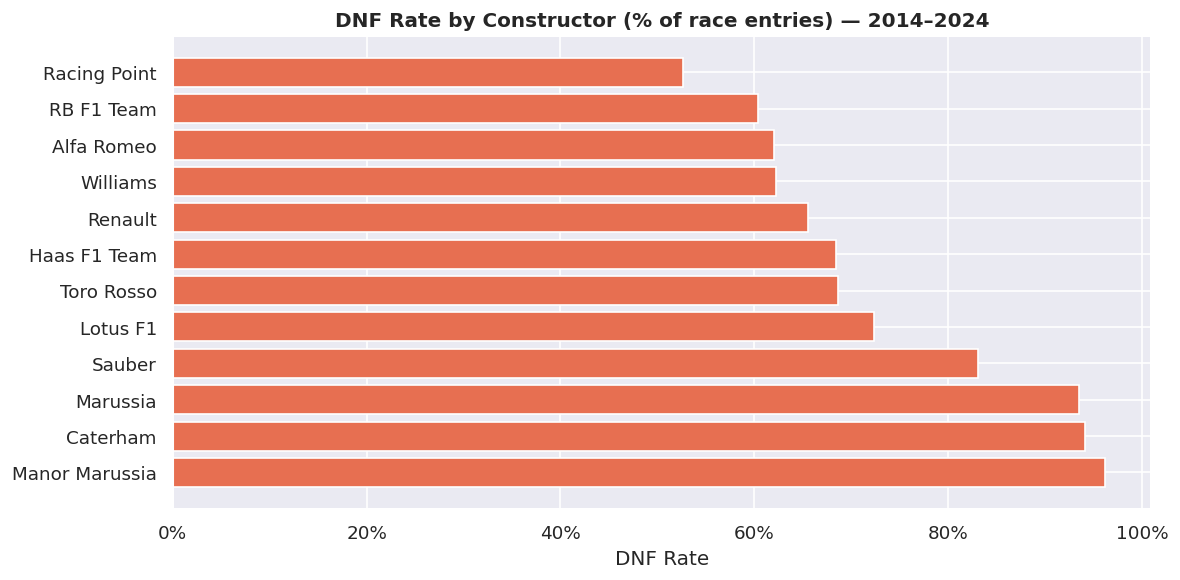

In [21]:
# ── EDA 5: DNF rate by constructor (reliability signal) ─────────────────────

# 1. Calculate total races entered per constructor (driver-race entries)
races_entered_df = res.groupby('constructor_id').size().reset_index(name='races_entered')

# 2. Calculate total DNFs per constructor
# A DNF is typically when the status is not 'Finished'
dnf_results = res[res['status'] != 'Finished']
total_dnfs_df = dnf_results.groupby('constructor_id').size().reset_index(name='total_dnfs')

# 3. Merge races_entered_df and total_dnfs_df
# Use an outer merge to ensure all constructors are included, even if they have 0 DNFs or 0 races
dnf_data = pd.merge(races_entered_df, total_dnfs_df, on='constructor_id', how='left')

# Fill NaN values for total_dnfs with 0, as a left merge might produce NaNs for constructors with no DNFs
dnf_data['total_dnfs'] = dnf_data['total_dnfs'].fillna(0).astype(int)

# 4. Merge with constructors_df to get 'name'
# Assuming constructors_df is already loaded as per previous cells
dnf_data = pd.merge(dnf_data, constructors_df[['constructor_id', 'name']], on='constructor_id', how='left')

# 5. Calculate DNF rate
dnf_data['dnf_rate'] = dnf_data['total_dnfs'] / dnf_data['races_entered']

# Filter for relevant constructors and sort as in the original code
dnf_plot_data = dnf_data.sort_values('dnf_rate', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dnf_plot_data['name'], dnf_plot_data['dnf_rate'], color='#e76f51')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('DNF Rate by Constructor (% of race entries) — 2014–2024',
             fontsize=12, fontweight='bold')
ax.set_xlabel('DNF Rate')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_05_dnf_rate.png', dpi=150)
plt.show()

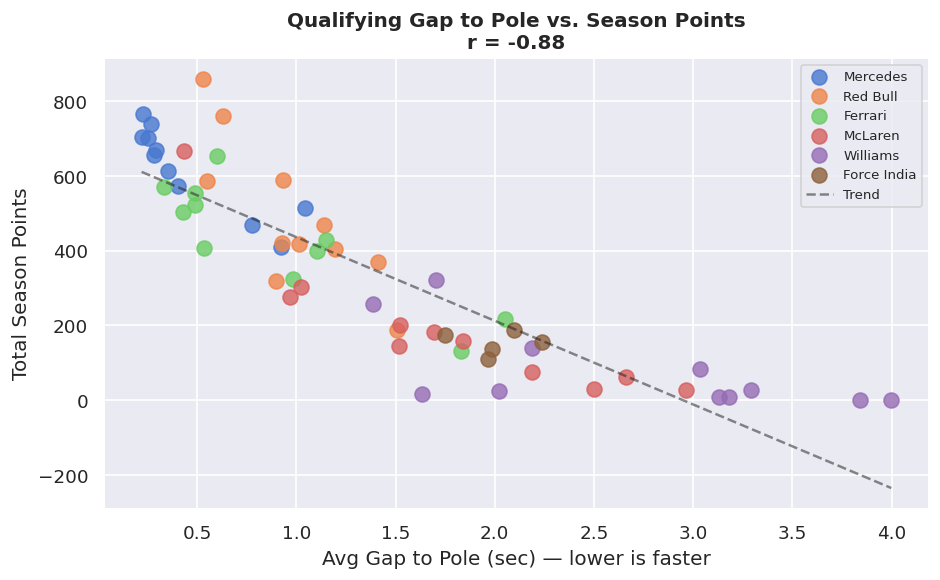

Pearson r = -0.884


In [23]:
import numpy as np
import pandas as pd # Ensure pandas is imported, though it usually is

# Helper function to convert time strings (MM:SS.mmm) to seconds
def time_to_seconds(time_str):
    if pd.isna(time_str):
        return np.nan
    try:
        if ':' in time_str:
            minutes, seconds = map(float, time_str.split(':'))
            return minutes * 60 + seconds
        else:
            # Handle cases where it might already be a float string or malformed
            return float(time_str)
    except ValueError:
        return np.nan

# 1. Process qualifying times: convert 'q1', 'q2', 'q3' to seconds
qual_processed = qual.copy()
for q_col in ['q1', 'q2', 'q3']:
    qual_processed[f'{q_col}_sec'] = qual_processed[q_col].apply(time_to_seconds)

# 2. Get the best qualifying time for each driver in each race
# This is the minimum time across q1_sec, q2_sec, q3_sec for that driver/race.
qual_processed['best_qual_time'] = qual_processed[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)

# 3. Determine the pole time for each race (minimum best_qual_time for that race)
pole_times_per_race = qual_processed.groupby('race_id')['best_qual_time'].min().reset_index()
pole_times_per_race.rename(columns={'best_qual_time': 'pole_time'}, inplace=True)

# 4. Merge pole times back to the processed qualifying data
qual_merged = pd.merge(qual_processed, pole_times_per_race, on='race_id', how='left')

# 5. Calculate the 'gap to pole' for each driver in each race
qual_merged['gap_to_pole'] = qual_merged['best_qual_time'] - qual_merged['pole_time']

# 6. Calculate the average 'gap to pole' for each constructor per season
avg_gap_to_pole_constructor_season = qual_merged.groupby(['season', 'constructor_id'])['gap_to_pole'].mean().reset_index()
avg_gap_to_pole_constructor_season.rename(columns={'gap_to_pole': 'avg_gap_to_pole'}, inplace=True)

# 7. Merge the calculated average gap to pole with the main constructor data (ts_with_names)
# ts_with_names contains 'total_points' and 'name' which are crucial for the plot.
ts_with_qual_data = pd.merge(ts_with_names, avg_gap_to_pole_constructor_season,
                             on=['season', 'constructor_id'], how='left')

# Now, `ts_with_qual_data` has 'avg_gap_to_pole' and 'total_points'.
# Proceed with the original plotting logic using `ts_with_qual_data`.
corr_df = ts_with_qual_data[ts_with_qual_data['constructor_id'].isin(TOP6)].dropna(
    subset=['avg_gap_to_pole', 'total_points'])

fig, ax = plt.subplots(figsize=(8, 5))
for cid in TOP6:
    sub = corr_df[corr_df['constructor_id'] == cid]
    name = sub['name'].iloc[0] if len(sub) else cid
    ax.scatter(sub['avg_gap_to_pole'], sub['total_points'],
               label=name, s=80, alpha=0.8)

# Trend line
x_all = corr_df['avg_gap_to_pole'].values
y_all = corr_df['total_points'].values

# Ensure there's enough data for polyfit and corrcoef
if len(x_all) > 1:
    m, b  = np.polyfit(x_all, y_all, 1)
    x_line = np.linspace(x_all.min(), x_all.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', alpha=0.5, label='Trend')
    corr_r = np.corrcoef(x_all, y_all)[0, 1]
else:
    print("Not enough data points to compute trend line or correlation for Qualifying Gap vs. Season Points.")
    corr_r = np.nan # Set correlation to NaN if not enough data

ax.set_title(f'Qualifying Gap to Pole vs. Season Points\nr = {corr_r:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Gap to Pole (sec) — lower is faster')
ax.set_ylabel('Total Season Points')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_06_qual_vs_points.png', dpi=150)
plt.show()
print(f'Pearson r = {corr_r:.3f}')

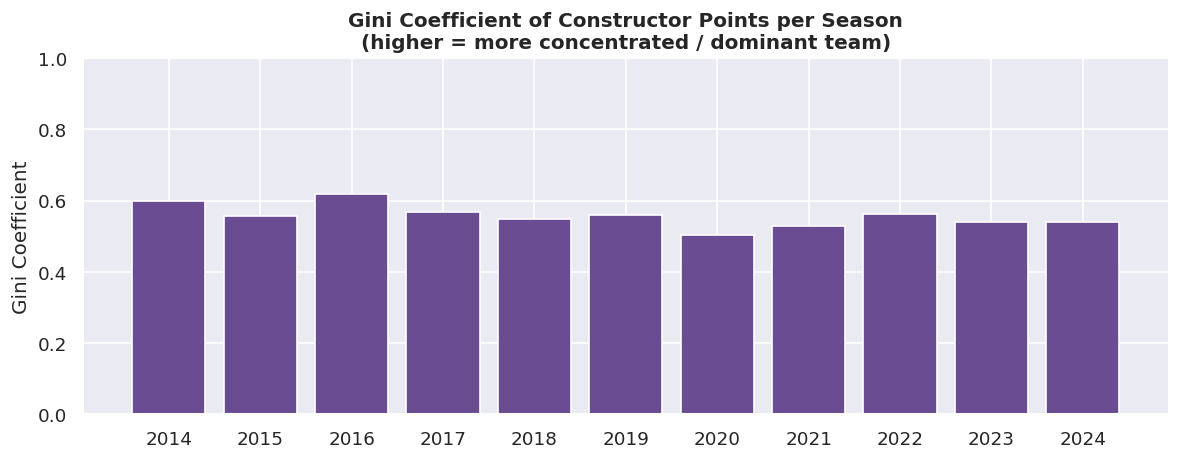

,season,gini
0,2014,0.597840
1,2015,0.555341
2,2016,0.618662
3,2017,0.566535
4,2018,0.549316
5,2019,0.560561
6,2020,0.503374
7,2021,0.527225
8,2022,0.563404
9,2023,0.539870


In [24]:
# ── EDA 7: Points distribution — Gini coefficient (sponsorship value concentration) ─
from itertools import combinations

def gini(arr):
    arr = np.sort(np.abs(arr))
    n   = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0
    return (2 * np.sum(np.arange(1, n+1) * arr) - (n + 1) * arr.sum()) / (n * arr.sum())

gini_by_season = ts.groupby('season')['total_points'].apply(gini).reset_index()
gini_by_season.columns = ['season', 'gini']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(gini_by_season['season'], gini_by_season['gini'], color='#6a4c93')
ax.set_title('Gini Coefficient of Constructor Points per Season\n(higher = more concentrated / dominant team)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Gini Coefficient')
ax.set_xticks(range(2014, 2025))
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/eda_07_gini.png', dpi=150)
plt.show()
gini_by_season

In [27]:
# ── EDA 8: Summary stats table for report ───────────────────────────────────

# The original error is `KeyError: 'name'` because `ts` does not have a 'name' column.
# We should use `ts_with_names` which was created by merging `ts` with `constructors_df`.

# First, calculate the season-level aggregates from ts_with_names
summary_base = ts_with_names.groupby('name').agg(
    seasons        = ('season',        'count'),
    avg_points     = ('total_points',  'mean'),
    avg_rank       = ('season_rank',   'mean'),
    total_wins     = ('wins',          'sum') # Use 'wins' from ts_with_names
)

# Add total podiums from temp_df_for_agg
# temp_df_for_agg already has season_podiums calculated and merged with constructor names
total_podiums_agg = temp_df_for_agg.groupby('name')['season_podiums'].sum().rename('total_podiums')
summary = summary_base.merge(total_podiums_agg, on='name', how='left')

# Add average dnf rate from dnf_data
# dnf_data already contains the aggregated dnf_rate per constructor name
dnf_rate_agg = dnf_data[['name', 'dnf_rate']].set_index('name') # Set index to name for merging
summary = summary.merge(dnf_rate_agg, on='name', how='left')
summary.rename(columns={'dnf_rate': 'avg_dnf_rate'}, inplace=True)

# Final formatting and sorting
summary = summary.round(2).sort_values('avg_rank')

print(summary.to_string())
summary.to_csv(f'{REPORTS_DIR}/summary_stats.csv')
print('Summary saved.')

                seasons  avg_points  avg_rank  total_wins  total_podiums  avg_dnf_rate
name                                                                                  
Mercedes             11      619.05      1.55         116              0          0.10
Red Bull             11      488.77      2.36          75              0          0.23
Ferrari              11      427.77      2.82          27              0          0.20
Force India           5      152.40      4.80           0              0          0.48
McLaren              11      193.18      5.18           7              0          0.47
Alpine F1 Team        4      128.25      5.25           1              0          0.45
Racing Point          2      134.00      5.50           1              0          0.53
Renault               5       91.80      5.80           0              0          0.66
Aston Martin          4      126.50      6.00           0              0          0.41
Lotus F1              2       44.00      7.

In [29]:
# ── EDA 9: Key findings printout (for progress report) ──────────────────────
print('=== KEY EDA FINDINGS ===')
print()
dom = ts_with_names.loc[ts_with_names['total_points'].idxmax()]
print(f'1. Most dominant season: {dom["name"]} in {dom["season"]} ({dom["total_points"]:.0f} pts)')

most_stable = stability.dropna().sort_values('rank_std').iloc[0]
print(f'2. Most consistent constructor: {most_stable["name"]} (rank std = {most_stable["rank_std"]:.2f})')

print(f'3. Correlation (qual gap → season pts): r = {corr_r:.3f}')

peak_gini = gini_by_season.loc[gini_by_season['gini'].idxmax()]
print(f'4. Most concentrated season (Gini): {peak_gini["season"]} (G = {peak_gini["gini"]:.3f})')

low_gini  = gini_by_season.loc[gini_by_season['gini'].idxmin()]
print(f'5. Most competitive season (lowest Gini): {low_gini["season"]} (G = {low_gini["gini"]:.3f})')
print()
print('These findings directly motivate the BVI weighting:')
print('- Strong qual-pace/points correlation → qualifying performance is a valid BVI input')
print('- High Gini years → adjust BVI to penalise field gaps (midfield sponsors deserve credit)')
print('- Consistency metric → risk-adjusted BVI component for long-term sponsor value')

=== KEY EDA FINDINGS ===

1. Most dominant season: Red Bull in 2023 (860 pts)
2. Most consistent constructor: Manor Marussia (rank std = 0.71)
3. Correlation (qual gap → season pts): r = -0.884
4. Most concentrated season (Gini): 2016.0 (G = 0.619)
5. Most competitive season (lowest Gini): 2020.0 (G = 0.503)

These findings directly motivate the BVI weighting:
- Strong qual-pace/points correlation → qualifying performance is a valid BVI input
- High Gini years → adjust BVI to penalise field gaps (midfield sponsors deserve credit)
- Consistency metric → risk-adjusted BVI component for long-term sponsor value
